## Loading the library and the dataset

In [7]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings('ignore')

df =pd.read_csv('IPL.csv')

### Basic Information 

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

#### check the size and shape of the array 

In [14]:
print(f"your rows {df.shape[0]} and columns {df.shape[1]}")

your rows 74 and columns 20


In [15]:
sums =df.isnull().sum()
sums

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

### which team won the most matches 

Text(0, 0.5, 'Match Winner')

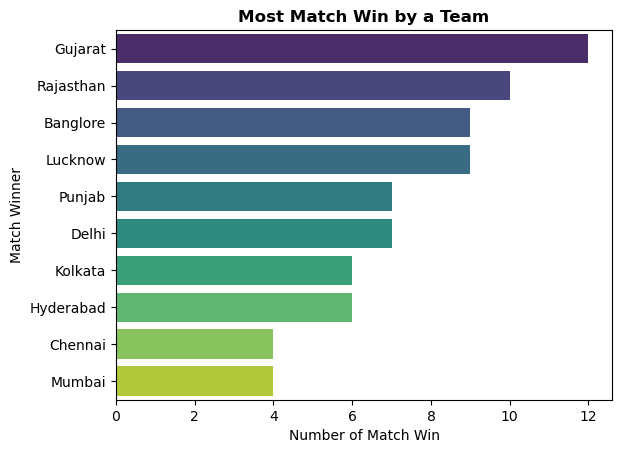

In [29]:
most_match_winners=df['match_winner'].value_counts()
sns.barplot(y=most_match_winners.index,x=most_match_winners.values,palette='viridis')
plt.title("Most Match Win by a Team",fontweight='bold',fontsize=12)
plt.xlabel('Number of Match Win')
plt.ylabel('Match Winner')

#### Toss decision Trends

Text(0, 0.5, 'Count')

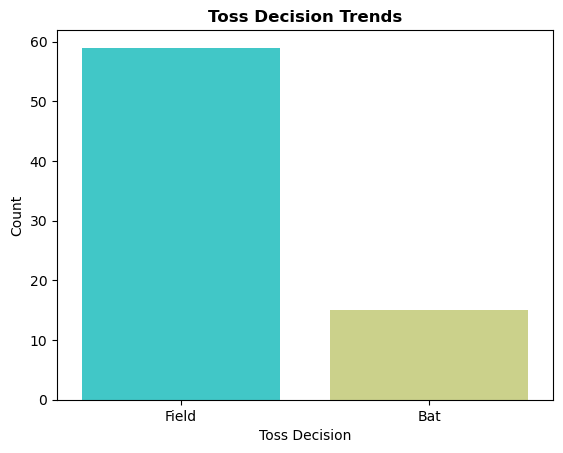

In [37]:
toss_decision =df['toss_decision']
sns.countplot(x=toss_decision,palette='rainbow')
plt.title("Toss Decision Trends",fontweight="bold")
plt.xlabel('Toss Decision')
plt.ylabel('Count')


#### Toss winner vs Match Winner 

In [41]:
count =df[df['toss_winner']==df['match_winner']]['match_id'].count()
percentage =count*100/df.shape[0]
percentage.round(2)

np.float64(48.65)

## How to teams wind run vs Wickets

Text(0.5, 1.0, 'Won By ')

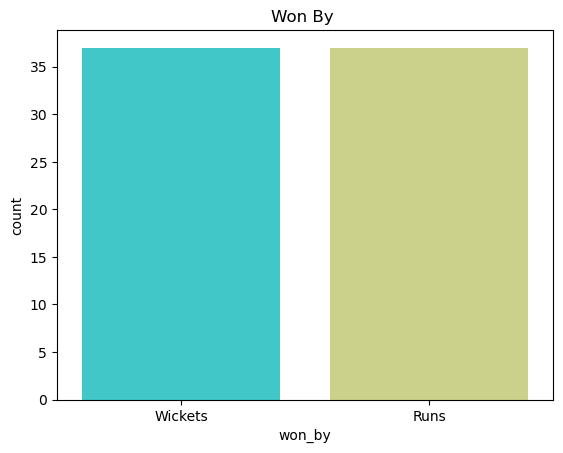

In [53]:
won_by =df['won_by']
sns.countplot(x=won_by,palette='rainbow')
plt.title("Won By ")

### Most player of the match awards

In [67]:
count =df['player_of_the_match'].value_counts().head(10)


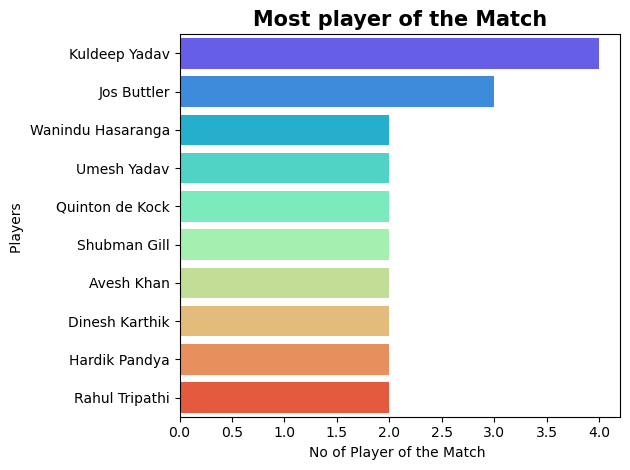

In [66]:
sns.barplot(y=count.index,x=count.values,palette='rainbow')
plt.title("Most player of the Match",fontweight="bold",fontsize=15)
plt.xlabel('No of Player of the Match ')
plt.ylabel('Players ')
plt.tight_layout()

### Top Scorer 

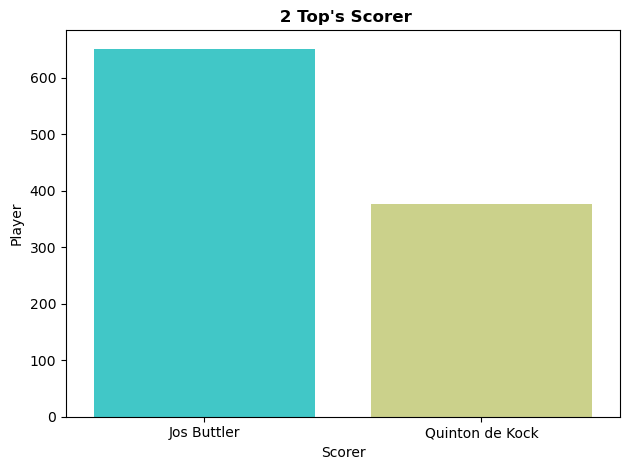

In [100]:
high =df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
sns.barplot(high,palette='rainbow')
plt.title(" 2 Top's Scorer",fontweight='bold')
plt.xlabel('Scorer')
plt.ylabel('Player')
plt.tight_layout()

## 10 Best Bowller

<Axes: ylabel='best_bowling'>

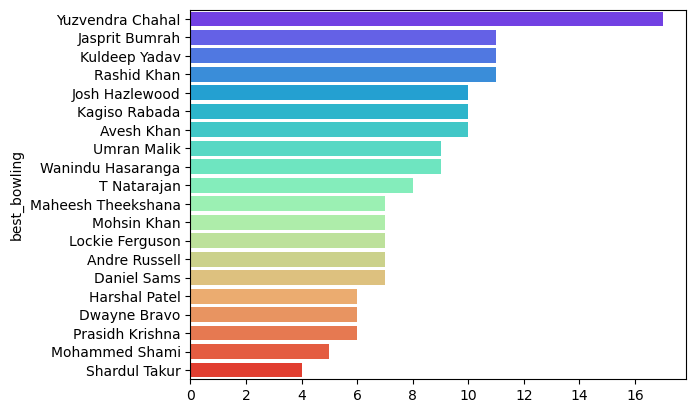

In [106]:
df['heighest_wickets'] =df['best_bowling_figure'].apply(lambda x:x.split('--')[0])
df['heighest_wickets'] =df['heighest_wickets'].astype(int)
best_bowler =df.groupby('best_bowling')['heighest_wickets'].sum().sort_values(ascending=False).head(20)
sns.barplot(y=best_bowler.index,x=best_bowler.values,palette='rainbow')

### Most match Played by vanues

<Axes: ylabel='venue'>

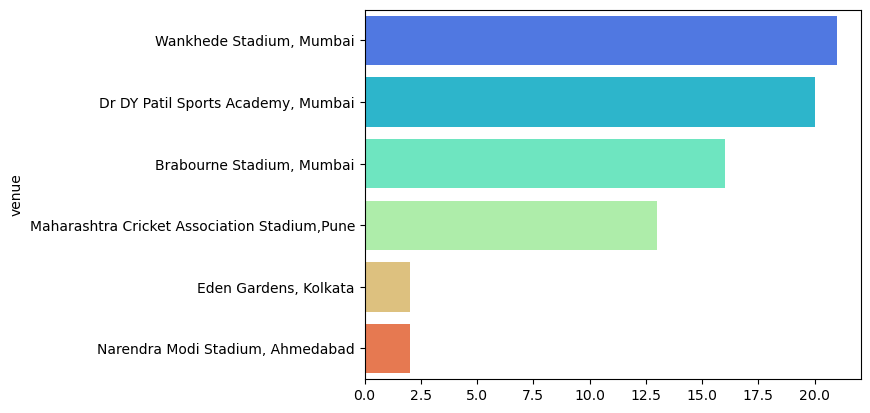

In [111]:
venue_count =df['venue'].value_counts()
sns.barplot(y=venue_count.index,x=venue_count.values,palette='rainbow')

### Heightest margin win by run 

In [125]:
highest_margin =df[df['won_by'] =='Runs'].sort_values(ascending=False, by='margin').head(1)[['match_winner','margin']]
highest_margin

,match_winner,margin
54,Chennai,91
